In [1]:
# House Price Prediction
#2.1 Load & Inspect
# Goal: understand the structure, data types, target variable, and missing-value pattern

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/house_prices.csv")

In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [7]:
df.isna().mean().sort_values(ascending=False) 

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [8]:
# - The dataset contains 187531 rows in total and 20 columns (exclusing the index column) (21 with the index)
# - Several variables that look numeric are stored as text, so they must be parsed before modeling
# - for the numeric columns, we have: Price (in rupees)(float), Dimensions(float), Plot Area(float), (& index column (int))
# - for the text columns (string), we have: Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing,
# overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area
# - Plot Area and Dimensions are completely missing, so they provide no usable information and can later be dropped.
# - Top 10 columns (in order) with missing values are: Plot Area(100% missing values), Dimensions(100% missing value), Society (58% missing values), 
# Super Area(57% missing values), Car Parking (55% missing values), overlooking(43% missing values), Carpet Area(43% missing values),
# facing(37% missing values), Ownership(34% missing values), Balcony (26% missing values)

In [9]:
df[["Amount(in rupees)", "Price (in rupees)"]].head(20)

,Amount(in rupees),Price (in rupees)
0,42 Lac,6000.0
1,98 Lac,13799.0
2,1.40 Cr,17500.0
3,25 Lac,NaN
4,1.60 Cr,18824.0
5,45 Lac,6618.0
6,16.5 Lac,2538.0
7,60 Lac,10435.0
8,60 Lac,10000.0
9,1.60 Cr,11150.0


In [10]:
# 2.3 Cleaning & Feature Engineering 
# handling inconsistencies and data types
# some pints in 2.3 is done before 2.2 to be able to handle any inconsistencies and correct the datatypes before EDA

In [11]:
# Handle "Price is text" problem:
# price column contains text values, to be able to work on this attribute efficiently (visualizations and prediction),
# we need to remove the text and convert it into a numeric attribute
# A new column, 'price_clean', is created instead of overwriting the raw column so the original data remains available
# for re-checking
# Since price_clean is now the target variable, rows containg null values in price_clean should be removed because we want a valid target to train on

In [12]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        
        return float(x.replace(",", ""))
    except ValueError:
        return None
        
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount) 
df = df.dropna(subset=["price_clean"])

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [14]:
# Handle "Areas are text" problem:
# 'Carpet Area' combines a number and a unit in the same string
# For consistency, all units are converted to square feet
# units we are unsure of their conversions are kept as missing rather than guessed to avoid incorrect conversions

In [15]:
df["Carpet Area"].dropna().str.extract(r"([A-Za-z]+)$")[0].unique()

<StringArray>
['sqft', 'sqm', 'sqyrd', 'acre', 'ground', 'bigha', 'marla', 'kanal']
Length: 8, dtype: str

In [16]:
df["Carpet Area"].dropna().str.extract(r"([A-Za-z]+)$")[0].value_counts()

0
sqft      95986
sqyrd      4658
sqm         870
acre          2
marla         2
kanal         2
ground        1
bigha         1
Name: count, dtype: int64

In [17]:
def parse_area(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        value = float(x.split()[0])
        unit = x.split()[-1]

        if unit == "sqft":
            return value

        elif unit == "sqm":
            return value * 10.764

        elif unit == "sqyrd":
            return value * 9

        elif unit == "acre":
            return value * 43560

        elif unit == "ground":
            return value * 2400

        else:
            return None

    except (ValueError, IndexError):
        return None

In [18]:
df['Carpet Area_clean'] = df['Carpet Area'].apply(parse_area)

In [19]:
df.loc[
    df["Carpet Area"].notna() & df["Carpet Area_clean"].isna(),
    "Carpet Area"
].value_counts()

Carpet Area
14 marla      2
1 kanal       2
1607 bigha    1
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [21]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,price_clean,Carpet Area_clean
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN,4200000.0,500.0
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN,9800000.0,473.0
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN,14000000.0,779.0
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,1,1,NaN,NaN,NaN,NaN,NaN,2500000.0,530.0
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN,16000000.0,635.0


In [22]:
# Handle "Floor" problem:
# 'Floor' contains both the property's floor and in some records, the building's total number of floors
# these are separated into two numeric variables to avoid information loss
# ground floor is encoded as 0. Basement labels are mapped to -1 

In [23]:
df["Floor"].dropna().str.extract(r"([A-Za-z]+(?:\s+[A-Za-z]+)*)")[0].unique()

<StringArray>
[               'out of',         'Ground out of', 'Upper Basement out of',
 'Lower Basement out of',                     nan,                'Ground',
        'Lower Basement']
Length: 7, dtype: str

In [24]:
df["Floor"].dropna().str.extract(r"([A-Za-z]+(?:\s+[A-Za-z]+)*)")[0].value_counts()

0
out of                   159938
Ground out of             10580
Upper Basement out of       210
Lower Basement out of       124
Ground                        4
Lower Basement                1
Name: count, dtype: int64

In [25]:
def parse_floor(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    if x.startswith("ground"):
        return 0

    elif x.startswith("lower basement"):
        return -1

    elif x.startswith("upper basement"):
        return -1

    else:
        try:
            return int(x.split()[0])
        except (ValueError, IndexError):
            return None

In [26]:
def parse_total_floors(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "out of" in x:
            return int(x.split("out of")[-1].strip())
        else:
            return None

    except ValueError:
        return None

In [27]:
df['Floor_num'] = df['Floor'].apply(parse_floor)
df["total_floors"] = df["Floor"].apply(parse_total_floors)

In [28]:
# handle Bathroom / Balcony / Car Parking data types

In [29]:
# values are stored as strings or special labels such as '> 10'

In [30]:
# Ensure that the column has numbers only that are stored as string values

In [31]:
df["Bathroom"].dropna().str.extract(r"([A-Za-z]+(?:\s+[A-Za-z]+)*)")[0].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [32]:
# Converting the values to numeric values

In [33]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [35]:
df.loc[
    df["Bathroom"].notna() & df["bathroom"].isna(),
    "Bathroom"
].value_counts()

Bathroom
> 10    29
Name: count, dtype: int64

In [36]:
# "> 10" cannot be converted directly to a number
# converting it to 11 preserves the information that the count exceeds 10

In [37]:
df["bathroom"] = df["Bathroom"].replace("> 10", 11)

df["bathroom"] = pd.to_numeric(
    df["bathroom"],
    errors="coerce"
)

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [39]:
# handle balcony datatype

In [40]:
# Ensure that the column has numbers only that are stored as string values

In [41]:
df["Balcony"].dropna().str.extract(r"([A-Za-z]+(?:\s+[A-Za-z]+)*)")[0].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [42]:
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [44]:
df.loc[
    df["Balcony"].notna() & df["balcony"].isna(),
    "Balcony"
].value_counts()

Balcony
> 10    16
Name: count, dtype: int64

In [45]:
# Apply the same rule used for bathrooms to the "> 10" balcony value

In [46]:
df["balcony"] = df["Balcony"].replace("> 10", 11)

df["balcony"] = pd.to_numeric(
    df["balcony"],
    errors="coerce"
)

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [48]:
# handle car parking datatype

In [49]:
# cheching for text in the car parking values

In [50]:
df["Car Parking"].dropna().str.extract(r"([A-Za-z]+(?:\s+[A-Za-z]+)*)")[0].unique()

<StringArray>
['Open', 'Covered']
Length: 2, dtype: str

In [51]:
df['Car Parking'].unique

<bound method Series.unique of 0                NaN
1             1 Open
2          1 Covered
3                NaN
4          1 Covered
             ...    
187526     1 Covered
187527     1 Covered
187528    1 Covered,
187529           NaN
187530     1 Covered
Name: Car Parking, Length: 177847, dtype: str>

In [52]:
# creating 2 new columns, one for the number of car parkings and one for the type to avoid loss of information

In [53]:
def parse_car_parking_type(x):
    if not isinstance(x,str):
        return None
    x = x.strip().lower().replace(",", "")
    try:
        return x.split(' ')[-1].strip()
    except ValueError:
        return None
    

In [54]:
def parse_car_parking_num(x):
    if not isinstance(x,str):
        return None
    x = x.strip().lower().replace(",", "")
    try:
        y = x.split(' ')[0].strip()
        return int(y)
    except ValueError:
        return None
    

In [55]:
df["car_parking_type"] = df["Car Parking"].apply(parse_car_parking_type)

df["car_parking_num"] = df["Car Parking"].apply(parse_car_parking_num)

In [56]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [57]:
df['car_parking_type'].unique().value_counts

<bound method StringArray.value_counts of <StringArray>
[nan, 'open', 'covered']
Length: 3, dtype: str>

In [58]:
# handle High-cardinality categoricals 'Society'
# 'Society' has many unique values. One-hot encoding every unique society would create a very large number of features
# and could lead to  overfitting
# rare societies are grouped into an 'other' category using a minimum-frequency threshold of 20 observations

In [59]:
df['Society'].nunique()

10068

In [60]:
df["Society"].value_counts().head(20)

Society
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
DDA Flat                         823
Rama Apartment                   823
Aadarsh Apartment                821
CGHS Apoorva Apartments          821
Him Hit Sadbhavna Apartments     821
DDA Sanskriti Apartments         821
Madhur Jeevan Apartment          821
Kesarwani Apartment              821
DLF New Town Heights             666
Elita Garden Vista               655
Mani Casa                        653
Name: count, dtype: int64

In [61]:
df["Society"].value_counts().describe()

count    10068.000000
mean         7.442193
std         55.496247
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1648.000000
Name: count, dtype: float64

In [62]:
society_counts = df["Society"].value_counts()

In [63]:
society_counts[society_counts < 20].sum()

np.int64(24102)

In [64]:
common_societies = society_counts[society_counts >= 20].index

In [65]:
df["society_clean"] = df["Society"].str.strip().str.lower()

In [66]:
society_counts = df["society_clean"].value_counts()

common_societies = society_counts[society_counts >= 20].index

df["society_grouped"] = df["society_clean"].where(
    df["society_clean"].isin(common_societies),
    "other"
)

df.loc[df["society_clean"].isna(), "society_grouped"] = None

In [67]:
df["society_grouped"].nunique()

238

In [68]:
df["society_grouped"].value_counts(dropna=False).head(20)

society_grouped
NaN                             102919
other                            24090
hamdam apartment                  1648
malibu town                       1158
shree vardhman victoria           1154
dlf skycourt                      1153
nebula tower                       982
harmony apartment                  828
defence officers apartment         827
east of kailash                    826
sarve satyam apartment             825
dda flat                           823
rama apartment                     823
aadarsh apartment                  821
cghs apoorva apartments            821
him hit sadbhavna apartments       821
dda sanskriti apartments           821
madhur jeevan apartment            821
kesarwani apartment                821
dlf new town heights               666
Name: count, dtype: int64

In [69]:
# handle High-cardinality categoricals 'location'
# To control dimensionality, only the 60 most frequent locations are retained as individual categories and all others
# are grouped as 'Other'
# 60 is just a randomly selected number

In [70]:
df['location'].nunique()

81

In [71]:
df['location'].value_counts().head(20)

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
Name: count, dtype: int64

In [72]:
df['location'].value_counts().describe()

count       81.000000
mean      2195.641975
std       5152.655966
min         26.000000
25%        119.000000
50%        443.000000
75%       1153.000000
max      24945.000000
Name: count, dtype: float64

In [73]:
df["location_clean"] = df["location"].str.strip().str.lower()
top_60_locations = df["location_clean"].value_counts().head(60).index

df["location_grouped"] = df["location_clean"].where(
    df["location_clean"].isin(top_60_locations),
    "Other"
)

In [74]:
df["location_grouped"].nunique()

61

In [75]:
# 2.2 Exploratory Data Analysis (EDA) 
# EDA is used to understand the target distribution, inspect relationships between features and price
# and identify extreme observations before model training

In [76]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [77]:
# distribution of the target price (with log scale)
# House prices are strongly right-skewed: most listings are concentrated at lower values while a small number are
# extremely expensive. A logarithmic x-axis makes the full distribution easier to inspect without deleting observations
# This plot changes only the visualization scale

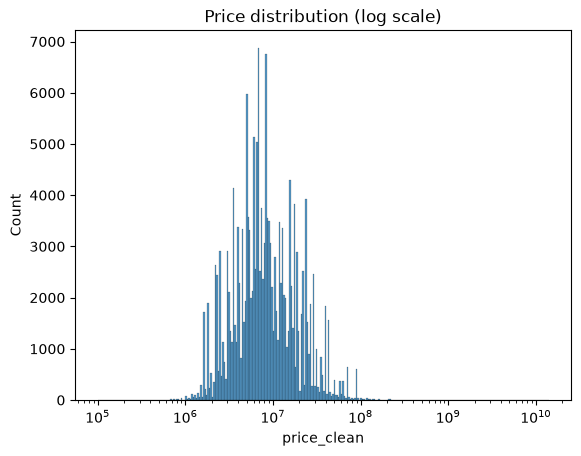

In [78]:
sns.histplot(df["price_clean"], log_scale=True) 
plt.title("Price distribution (log scale)") 
plt.show()

In [79]:
# distribution of the target without log scale
# The original scale histogram is kept for comparison. It shows why the log-scale view is useful

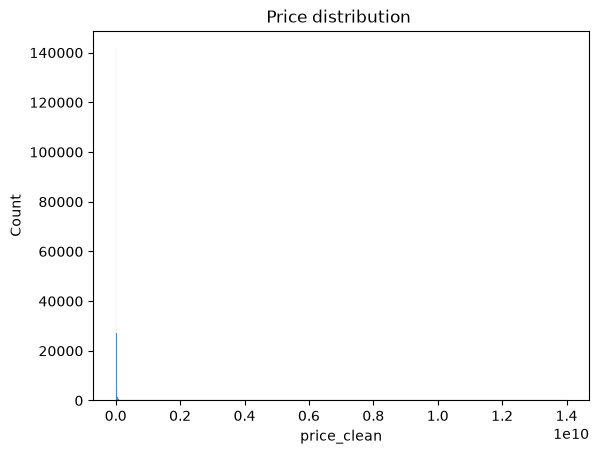

In [80]:
sns.histplot(df["price_clean"]) 
plt.title("Price distribution ") 
plt.show()

In [81]:
# In a normal graph, the distance between the values is equal to the numeric difference between them,
# and because the prices of the houses contain  mostly small values and few extremly large values relative to these small values
# the normal graph sqweezes the small values together at the extreme left so that the extrem large values van also appear in the graph at the right
# to solve this, we used log scale so that the distance between the values in the graph gets bigger with each step taken
# (distance is multiplied rather than added), this gives more space to small values and squeezes larger values

In [82]:
# Price vs. carpet area (scatter)
# A scatter plot is used to check whether larger homes generally have higher prices, and to mailny inspect the relationship
# between price and carpet area

<Axes: xlabel='Carpet Area_clean', ylabel='price_clean'>

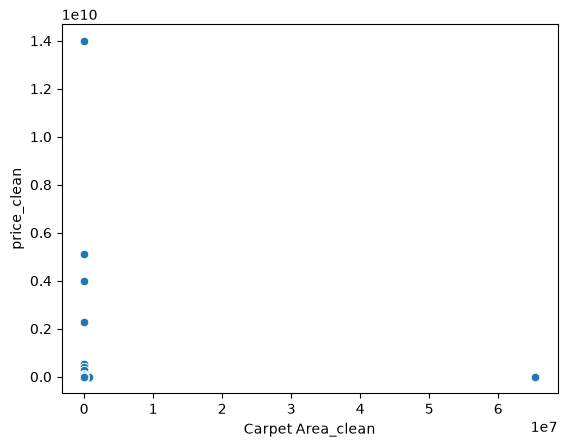

In [83]:
sns.scatterplot(
    data=df,
    x="Carpet Area_clean",
    y="price_clean"
)

In [84]:
# there are extreme points with extremely high carpet area value higher than 6e7 sqft and points with extremely high price
# approximately 1.4e10 sqft these values strech the graph to the top and to the roght
# that's why the graph has extended y and x axis and all normal values are squeezed in the bottom left

In [85]:
df.nlargest(
    10,
    "Carpet Area_clean"
)[["Carpet Area", "Carpet Area_clean", "Amount(in rupees)", "price_clean", "location"]]

,Carpet Area,Carpet Area_clean,Amount(in rupees),price_clean,location
93644,1500 acre,65340000.0,55 Lac,5500000.0,kolkata
165733,709222 sqft,709222.0,60 Lac,6000000.0,guwahati
149239,495970 sqft,495970.0,19 Lac,1900000.0,bhiwadi
147580,282004 sqft,282004.0,20 Lac,2000000.0,agra
50895,194936 sqft,194936.0,2.60 Cr,26000000.0,gurgaon
147791,113134 sqft,113134.0,56 Lac,5600000.0,agra
82876,107806 sqft,107806.0,68 Lac,6800000.0,jaipur
113787,2 acre,87120.0,1.80 Cr,18000000.0,lucknow
180072,81845 sqft,81845.0,45 Lac,4500000.0,thrissur
176689,81675 sqft,81675.0,45.7 Lac,4570000.0,siliguri


In [86]:
df["Carpet Area_clean"].describe()

count    1.015170e+05
mean     1.934942e+03
std      2.050938e+05
min      1.000000e+00
25%      8.500000e+02
50%      1.100000e+03
75%      1.550000e+03
max      6.534000e+07
Name: Carpet Area_clean, dtype: float64

In [87]:
# checking to see which quartile the outliers lie in

In [88]:
df["Carpet Area_clean"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    2000.00
0.950    2550.00
0.990    4583.00
0.995    4734.00
0.999    6819.36
Name: Carpet Area_clean, dtype: float64

In [89]:
# restrict the axes to the main data range for visualization only
# This does NOT delete any observations

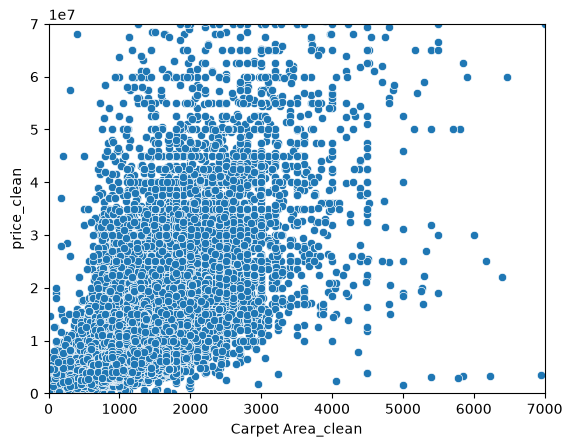

In [90]:
sns.scatterplot(
    data=df,
    x="Carpet Area_clean",
    y="price_clean"
)

plt.xlim(0, 7000)
plt.ylim(0, df["price_clean"].quantile(0.99))
plt.show()

In [91]:
# the graph does not show a strong linear relationship between the carpet area and the price
# there is a variation in price for the same carpet area, this indicates that carpet area alone is not a strong predictor of price

In [92]:
# LOCATION AND PRICE
# Average price by top-15 locations (bar chart)

In [93]:
top_15_locations = df["location_clean"].value_counts().head(15).index

In [94]:
avg_price_by_location = (
    df[df["location_clean"].isin(top_15_locations)]
    .groupby("location_clean")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)
avg_price_by_location

location_clean
mumbai           3.355292e+07
gurgaon          2.170470e+07
new-delhi        1.616784e+07
hyderabad        1.526815e+07
chennai          1.139704e+07
vadodara         1.082852e+07
pune             1.052901e+07
ahmedabad        1.027555e+07
bangalore        1.006305e+07
thane            9.712493e+06
faridabad        8.752084e+06
kolkata          8.707460e+06
surat            8.449050e+06
greater-noida    7.734287e+06
jaipur           6.450960e+06
Name: price_clean, dtype: float64

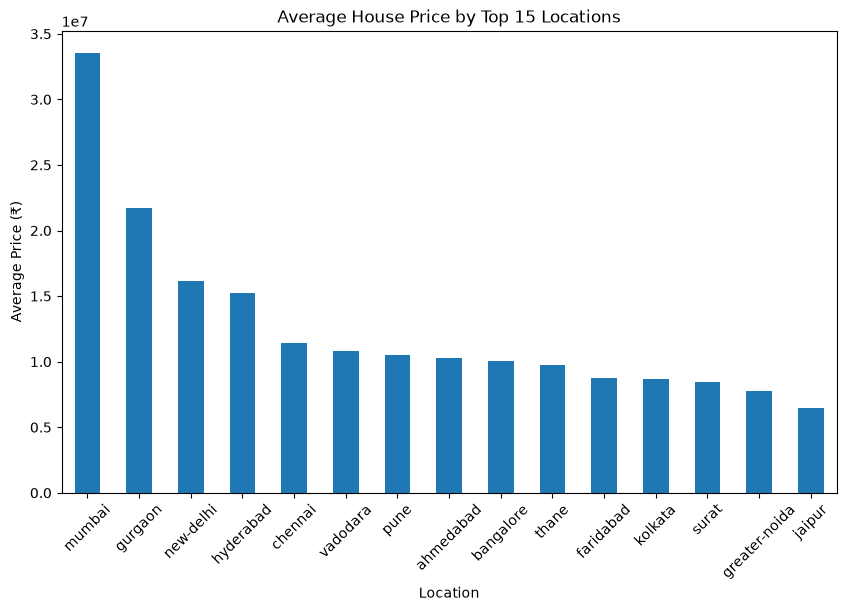

In [95]:
avg_price_by_location.plot(kind="bar", figsize=(10, 6))

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)
plt.show()

In [96]:
# the bar chart shows that the average price is clearly different from one location to the other, which indicates
# that the price has a strong relationship with the location

In [97]:
#Price by furnishing status / number of bathrooms (box plots)
# Box plots compare the distribution of prices across furnishing categories

In [98]:
df['Furnishing'].unique()

<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished', nan]
Length: 4, dtype: str

In [99]:
df['Furnishing'].value_counts()

Furnishing
Semi-Furnished    82868
Unfurnished       73491
Furnished         19421
Name: count, dtype: int64

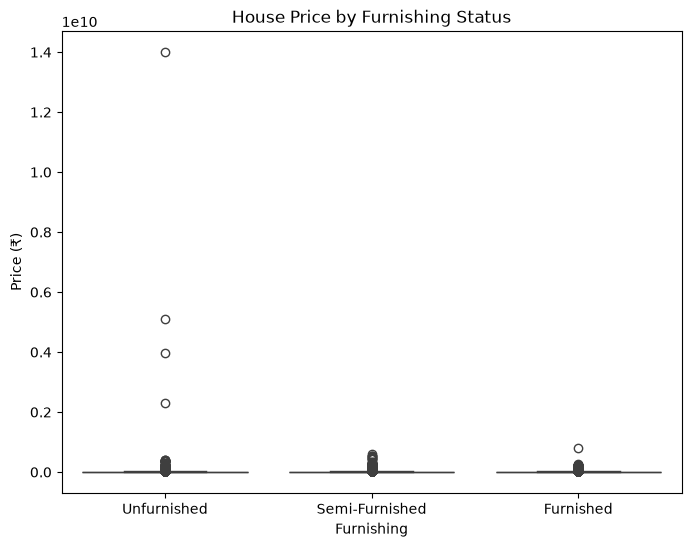

In [100]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (₹)")
plt.show()

In [101]:
df["price_clean"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     24000000.0
0.950     33900000.0
0.990     70000000.0
0.995     89600000.0
0.999    125000000.0
Name: price_clean, dtype: float64

In [102]:
# we also disgard the outliers and limit the boxplot to the suitable data range without extreme values
#this is for visualization only, no data was deleted

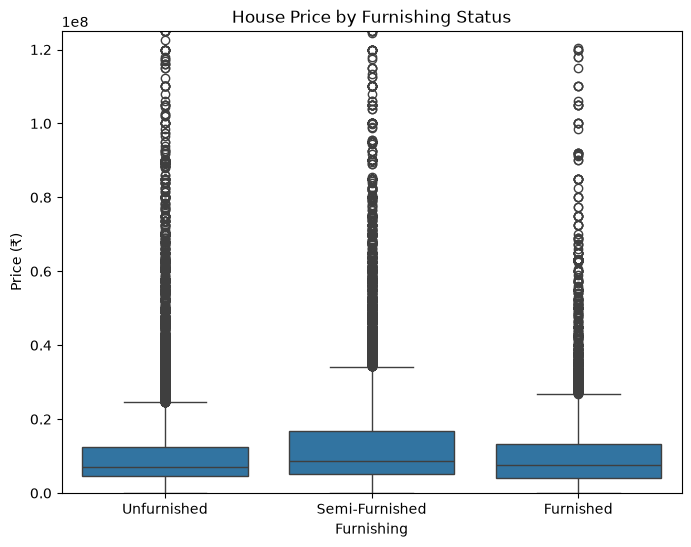

In [103]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.ylim(0, df["price_clean"].quantile(0.999))

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (₹)")
plt.show()

In [104]:
# semi-furnished furnishing shows the highest median price from other categories, however, the categories overlap
# we cannot infer that more furniture leads to higher price, this plot does not establish a causal relationship between furnishing and price

In [105]:
# 2.3 Cleaning & Feature Engineering 
# handle missing values, outliers and feature selection
# Imputation for model features is performed inside the training pipeline

In [106]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

(array([1.5509e+04, 8.8999e+04, 5.4187e+04, 1.4826e+04, 3.2810e+03,
        1.8700e+02, 3.2000e+01, 1.4000e+01, 1.1000e+01, 4.1000e+01]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]),
 <BarContainer object of 10 artists>)

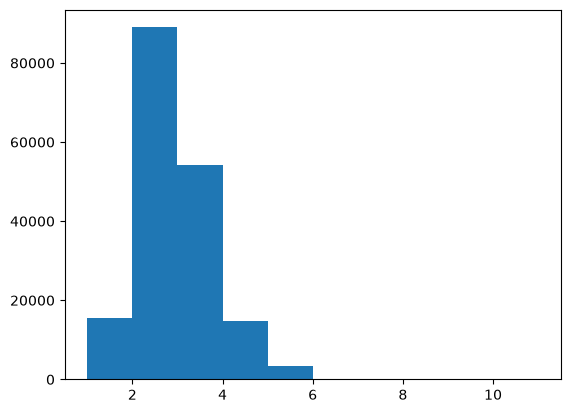

In [107]:
plt.hist(df['bathroom'], bins = 10)

In [108]:
# since the bathroom is right skewed, we will impute its missing values with the median rather than the mean, however, it will be done in the
# pipleine after splitting to avoid data leakage
# The median is less sensitive to unusually large bathroom counts.

(array([4.5145e+04, 5.0311e+04, 2.4958e+04, 9.2750e+03, 8.1400e+02,
        1.2700e+02, 1.4000e+01, 1.3000e+01, 2.0000e+00, 2.9000e+01]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]),
 <BarContainer object of 10 artists>)

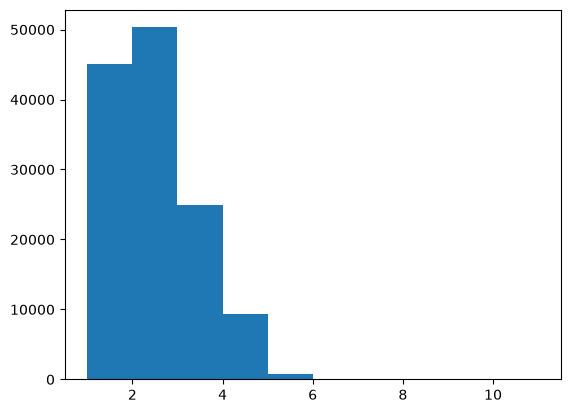

In [109]:
plt.hist(df['balcony'], bins = 10)

In [110]:
# balcony is also right-skewed, so it will be later replaced with the median

In [111]:
# since car parking is not included in the pipeline, we can impute its missing values, and it will not cause data leakage

In [112]:
df["car_parking_num"] = df["car_parking_num"].fillna(
    df["car_parking_num"].median()
)

In [113]:
df["car_parking_num"].isna().sum()

np.int64(0)

In [114]:
# impute car parking type by mode

In [115]:
df["car_parking_type"] = df["car_parking_type"].fillna(
    df["car_parking_type"].mode()[0]
)

In [116]:
print(df["car_parking_num"].isna().sum())
print(df["car_parking_type"].isna().sum())

0
0


In [117]:
# Drop useless columns

In [118]:
df = df.drop(
    columns=[
        "Index",
        "Title",
        "Description",
        "Dimensions",
        "Plot Area"
    ]
)

In [119]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  177847 non-null  str    
 1   Price (in rupees)  169866 non-null  float64
 2   location           177847 non-null  str    
 3   Carpet Area        101522 non-null  str    
 4   Status             177252 non-null  str    
 5   Floor              170898 non-null  str    
 6   Transaction        177780 non-null  str    
 7   Furnishing         175780 non-null  str    
 8   facing             112111 non-null  str    
 9   overlooking        102022 non-null  str    
 10  Society            74928 non-null   str    
 11  Bathroom           177087 non-null  str    
 12  Balcony            130688 non-null  str    
 13  Car Parking        81935 non-null   str    
 14  Ownership          115922 non-null  str    
 15  Super Area         76235 non-null   str    
 16  price_clean       

In [120]:
# handling outliers
# Extreme observations can dominate squared-error-based models
# Instead of filtering only on raw price or raw area, price per square foot is used as a check because it
# combines the two variables and can reveal inconsistent price-area combinations.

In [121]:
df[[
    "Amount(in rupees)",
    "price_clean",
    "Price (in rupees)",
    "Carpet Area",
    "Super Area"
]].head(20)

,Amount(in rupees),price_clean,Price (in rupees),Carpet Area,Super Area
0,42 Lac,4200000.0,6000.0,500 sqft,NaN
1,98 Lac,9800000.0,13799.0,473 sqft,NaN
2,1.40 Cr,14000000.0,17500.0,779 sqft,NaN
3,25 Lac,2500000.0,NaN,530 sqft,NaN
4,1.60 Cr,16000000.0,18824.0,635 sqft,NaN
5,45 Lac,4500000.0,6618.0,NaN,680 sqft
6,16.5 Lac,1650000.0,2538.0,550 sqft,NaN
7,60 Lac,6000000.0,10435.0,NaN,575 sqft
8,60 Lac,6000000.0,10000.0,NaN,600 sqft
9,1.60 Cr,16000000.0,11150.0,900 sqft,NaN


In [122]:
# create a new column (price per sqft) which is calculated as price_clean/carpet area_clean
# It is used only as a diagnostic for identifying extreme price-area combinations.

In [123]:
df["price_per_sqft"] = (
    df["price_clean"] / df["Carpet Area_clean"]
)

In [124]:
df["price_per_sqft"].describe()

count    1.015170e+05
mean     1.019687e+04
std      5.109348e+04
min      8.417508e-02
25%      5.247432e+03
50%      7.800000e+03
75%      1.236087e+04
max      1.118450e+07
Name: price_per_sqft, dtype: float64

In [125]:
df["price_per_sqft"].quantile([0.01, 0.99])

0.01     2696.347826
0.99    36000.000000
Name: price_per_sqft, dtype: float64

In [126]:
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

df.loc[
    (df["price_per_sqft"] < lower) |
    (df["price_per_sqft"] > upper),
    ["price_clean", "Carpet Area", "Carpet Area_clean", "price_per_sqft", "location"]
].sort_values("price_per_sqft")

,price_clean,Carpet Area,Carpet Area_clean,price_per_sqft,location
93644,5.500000e+06,1500 acre,65340000.0,8.417508e-02,kolkata
149239,1.900000e+06,495970 sqft,495970.0,3.830877e+00,bhiwadi
147580,2.000000e+06,282004 sqft,282004.0,7.092098e+00,agra
165733,6.000000e+06,709222 sqft,709222.0,8.459974e+00,guwahati
176420,3.060000e+06,69825 sqft,69825.0,4.382385e+01,siliguri
...,...,...,...,...,...
172072,3.500000e+06,1 sqft,1.0,3.500000e+06,mysore
174894,3.967500e+09,920 sqft,920.0,4.312500e+06,raipur
176536,5.100400e+09,970 sqft,970.0,5.258144e+06,siliguri
185837,7.000000e+06,1 sqft,1.0,7.000000e+06,visakhapatnam


In [127]:
print("Lower cutoff:", lower)
print("Upper cutoff:", upper)

Lower cutoff: 2696.3478260869565
Upper cutoff: 36000.0


In [128]:
# The 1st and 99th percentiles are chosen to remove only the most extreme combinations
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

df = df[
    df["price_per_sqft"].isna() |
    (
        (df["price_per_sqft"] >= lower) &
        (df["price_per_sqft"] <= upper)
    )
]

In [129]:
df.shape

(176202, 29)

In [130]:
df["price_per_sqft"].describe()

count    99872.000000
mean      9588.799185
std       5874.511976
min       2700.000000
25%       5350.000000
50%       7800.000000
75%      12298.558100
max      36000.000000
Name: price_per_sqft, dtype: float64

In [131]:
# 2.4 Build a Pipeline & Train
# Two models are compared:
# 1) Linear Regression: a simple, interpretable baseline
# 2) Gradient Boosting Regressor: a nonlinear ensemble model that can capture interactions and nonlinear relationships

In [132]:
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression 

numeric_features = ["Carpet Area_clean", "Floor_num", "bathroom", "balcony"] 

categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df[numeric_features + categorical_features] 
y = df["price_clean"] 

#Split the data first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

preprocessor = ColumnTransformer([ 
("num", Pipeline([("impute", SimpleImputer(strategy="median")), 
("scale", StandardScaler())]), numeric_features), 
("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), 
("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),]) 

In [133]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [134]:
gradient_boost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [135]:
linear_model.fit(X_train, y_train)

gradient_boost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Carpet Area_clean','Floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [136]:
# 2.5 Evaluate
# Performance is assessed using:
# - MAE: average absolute prediction error; easy to interpret in rupees.
# - RMSE: penalizes large prediction errors more strongly than MAE.
# - R²: proportion of variation in price explained 

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_gb = gradient_boost_model.predict(X_test)

# Linear Regression metrics
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

#Gradient boost metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)



Linear Regression
MAE: 4458565.66565054
RMSE: 8862136.197843494
R²: 0.5666863314880917
Gradient Boosting
MAE: 3633172.117246381
RMSE: 7569747.8032603795
R²: 0.6838535063097197


In [138]:
# LOG-TARGET
# since the price is skewed, we will try training on log(1 + price) 
# A log target can reduce the influence of very expensive properties and make the model focus more on relative
# differences in price. Predictions are transformed back to rupees before evaluation so all models are comparable

In [139]:
# Log-transform the training target
y_train_log = np.log1p(y_train)

# Linear Regression with log target
linear_log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_log_model.fit(X_train, y_train_log)

# Gradient Boosting with log target
gradient_boost_log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_boost_log_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Carpet Area_clean','Floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [140]:
# Predictions in original rupee scale
y_pred_linear_log = np.expm1(
    linear_log_model.predict(X_test)
)

y_pred_gb_log = np.expm1(
    gradient_boost_log_model.predict(X_test)
)

In [141]:
# Evaluate log-target models

In [142]:
# Linear Regression with log target
linear_log_mae = mean_absolute_error(y_test, y_pred_linear_log)
linear_log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear_log)
)
linear_log_r2 = r2_score(y_test, y_pred_linear_log)

# Gradient Boosting with log target
gb_log_mae = mean_absolute_error(y_test, y_pred_gb_log)
gb_log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_gb_log)
)
gb_log_r2 = r2_score(y_test, y_pred_gb_log)

print("Linear Regression - Log Target")
print("MAE:", linear_log_mae)
print("RMSE:", linear_log_rmse)
print("R²:", linear_log_r2)

print("\nGradient Boosting - Log Target")
print("MAE:", gb_log_mae)
print("RMSE:", gb_log_rmse)
print("R²:", gb_log_r2)

Linear Regression - Log Target
MAE: 12356229.451855155
RMSE: 1376776347.4630244
R²: -10457.089182422611

Gradient Boosting - Log Target
MAE: 3609783.779580606
RMSE: 8924086.22696325
R²: 0.5606070705871917


In [143]:
# The log-transformed Linear Regression clearly failed. An R² of -10457 means it performs dramatically worse than simply predicting the mean price
# This can happen because Linear Regression can produce extreme predictions on the log scale

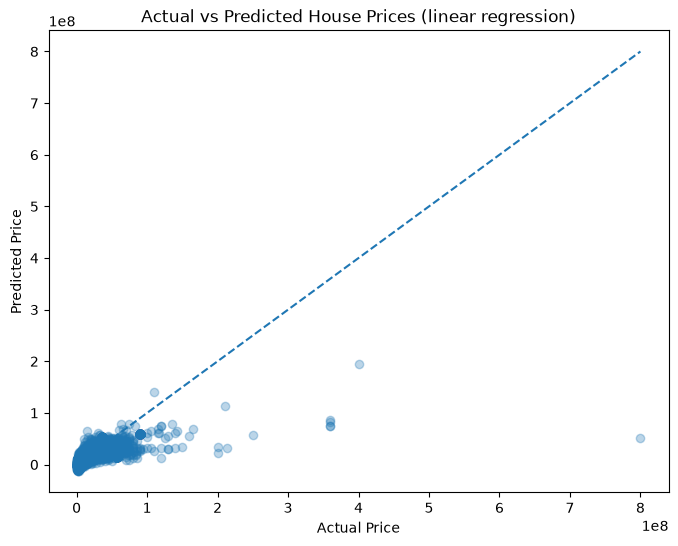

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.3
)

# Perfect-prediction reference line
min_price = min(y_test.min(), y_pred_gb_log.min())
max_price = max(y_test.max(), y_pred_gb_log.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (linear regression)")

plt.show()

In [145]:
# The model captures the general direction of prices, but the observations become increasingly far from the dashed perfect-prediction line 
# for expensive properties, it tends to underpredict very expensive houses

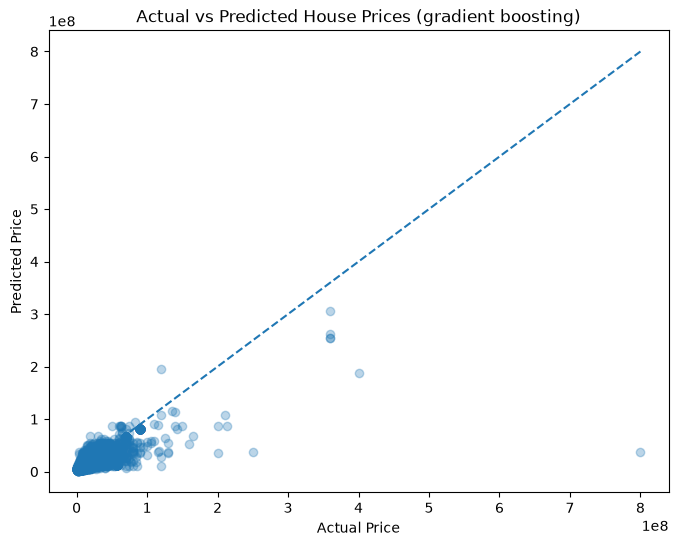

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.3
)

# Perfect-prediction reference line
min_price = min(y_test.min(), y_pred_gb_log.min())
max_price = max(y_test.max(), y_pred_gb_log.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (gradient boosting)")

plt.show()

In [147]:
# This is visibly better. More observations are concentrated around the diagonal
# It still underpredicts some extremely expensive properties

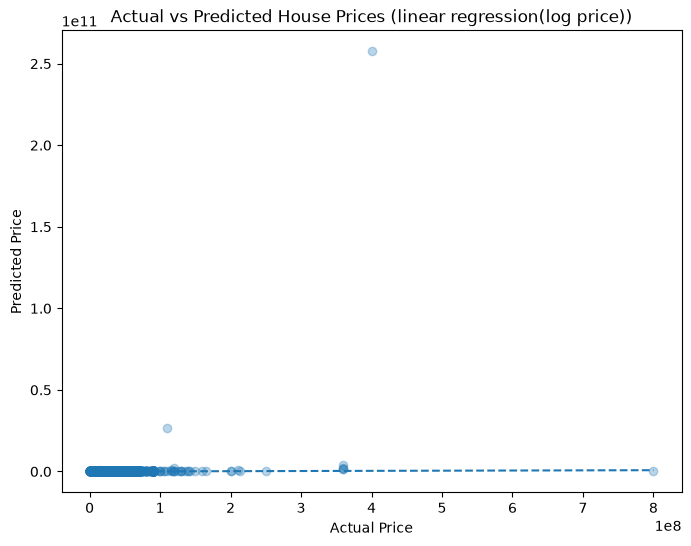

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear_log,
    alpha=0.3
)

# Perfect-prediction reference line
min_price = min(y_test.min(), y_pred_gb_log.min())
max_price = max(y_test.max(), y_pred_gb_log.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (linear regression(log price))")

plt.show()

In [149]:
# Linear Regression did not behave well when the target was log-transformed because some predicted log values became extremely
# large prices after being converted back with expm1()
# There are a few enormous predicted values

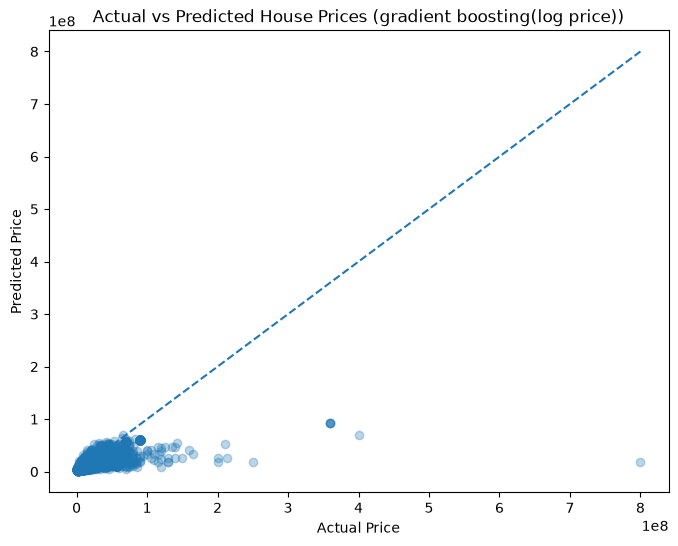

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_gb_log,
    alpha=0.3
)

# Perfect-prediction reference line
min_price = min(y_test.min(), y_pred_gb_log.min())
max_price = max(y_test.max(), y_pred_gb_log.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (gradient boosting(log price))")

plt.show()

In [151]:
# This is much more stable than log-Linear Regression. There is no prediction explosion
# it underpredicted many of the highest-priced properties

In [152]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear Regression - Log Target",
        "Gradient Boosting",
        "Gradient Boosting - Log Target"
    ],
    
    "MAE": [
        linear_mae,
        linear_log_mae,
        gb_mae,
        gb_log_mae
    ],
    
    "RMSE": [
        linear_rmse,
        linear_log_rmse,
        gb_rmse,
        gb_log_rmse
    ],
    
    "R²": [
        linear_r2,
        linear_log_r2,
        gb_r2,
        gb_log_r2
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,4.458566e+06,8.862136e+06,0.566686
1,Linear Regression - Log Target,1.235623e+07,1.376776e+09,-10457.089182
2,Gradient Boosting,3.633172e+06,7.569748e+06,0.683854
3,Gradient Boosting - Log Target,3.609784e+06,8.924086e+06,0.560607


In [153]:
# Model comparison: 
# Among the evaluated models, Gradient Boosting trained on the original price target provided the strongest overallpredictive performance
# It achieved an MAE of approximately 3.63 million rupees, an RMSE of 7.57 million rupees, and an R² of 0.684. 
# Although the log-transformed Gradient Boosting model produced a marginally lower MAE of approximately 3.61 million rupees, 
# its RMSE was higher and its R² decreased to 0.561. Therefore, the original-target Gradient Boosting model is better 
# because it provided the best overall balance of prediction accuracy and explanatory performance
# Linear Regression performed less effectively, while log-transforming the target substantially worsened the Linear Regression results.

In [154]:
# cross-validation with the winning model
# The best-performing held-out model is evaluated with 5-fold cross-validation to test whether its performance is stable
# across different subsets of the data rather than depending on one lucky 80/20 split
# Each observation is used for validation once and for training in the other four folds

In [155]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gradient_boost_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² scores: [ 0.47479574  0.44184351  0.4601228   0.37946279 -0.23385545]
Mean CV R²: 0.30447387913569723
Standard Deviation: 0.271119290056566


In [157]:
# Interpretation of the validation results
# On the original 80/20 split, Gradient Boosting achieved an R² of about 0.684, meaning it explained about 68.4% of the
# variation in test-set prices relative to a mean-price baseline
# The 5-fold cross-validation mean is notably lower and the fold scores vary substantially. This suggests that the model's
# performance is not fully stable across different subsets of the data.
# Therefore, the single test-set R² should not be presented as the model's expected performance in all samples.
# Possible next steps include inspecting why particular folds perform poorly, tuning hyperparameters with cross-validation,
# improving location/area features, and using shuffled K-fold validation where appropriate.


In [158]:
# 2.6 Export the Model
#The final Gradient Boosting pipeline is exported so that it can later be loaded by the FastAPI backend without retraining the model
#The exported pipeline contains both the preprocessing steps and the trained model

In [159]:
import joblib

In [160]:
joblib.dump(gradient_boost_model, "house_price.pkl")

['house_price.pkl']

In [161]:
import os

In [162]:
print(os.path.exists("house_price.pkl"))

True


In [163]:
loaded_model = joblib.load("house_price.pkl")

In [165]:
sample = X_test.iloc[[0]] 
print("Reloaded prediction:", loaded_model.predict(sample))

Reloaded prediction: [12957518.85813857]


In [169]:
print(gradient_boost_model.predict(sample))

[12957518.85813857]


In [170]:
import json

locations = sorted(
    df["location_grouped"]
    .dropna()
    .unique()
    .tolist()
)

with open("locations.json", "w") as f:
    json.dump(locations, f)

In [171]:
print(os.path.exists("locations.json"))

True


In [172]:
import sklearn

print(sklearn.__version__)

1.9.0


In [173]:
# ### Model Export
# The final Gradient Boosting pipeline was exported as `house_price.pkl`. The exported object includes both the preprocessing pipeline 
# and the trained Gradient Boosting Regressor, allowing raw model input features to be passed directly to the pipeline
# The grouped locations were also exported to `locations.json` for use in the frontend location dropdown
# The scikit-learn version used to train and export the model is 1.9.0
# The backend should use the same version to avoid model compatibility problems

In [175]:
import os
print(os.getcwd())

C:\Users\express\house-price-project\notebooks
